# Лабораторная работа №3

## Локализация точки

В ноутбуке выполнены оба задания лабораторной:
- пересечение отрезков тремя методами;
- локализация точки относительно простого невыпуклого многоугольника.

Для вычислений и визуализации используются `numpy` и `matplotlib`.


In [1]:
import math
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


## Вспомогательные функции

Ниже собраны:
- примитивы вычислительной геометрии для отрезков;
- учебная реализация заметающей прямой;
- угловой и лучевой методы локализации точки;
- функции визуализации.


In [2]:
EPS = 1e-9


@dataclass
class Segment:
    name: str
    a: tuple[float, float]
    b: tuple[float, float]

    def __post_init__(self):
        self.a = tuple(map(float, self.a))
        self.b = tuple(map(float, self.b))
        if abs(self.a[0] - self.b[0]) < EPS:
            raise ValueError("Вертикальные отрезки в этом ноутбуке не используются")
        self.left, self.right = (self.a, self.b) if self.a[0] < self.b[0] else (self.b, self.a)

    def y_at(self, x: float) -> float:
        (x1, y1), (x2, y2) = self.a, self.b
        return y1 + (x - x1) * (y2 - y1) / (x2 - x1)


def det_cross(ax: float, ay: float, bx: float, by: float) -> float:
    return ax * by - ay * bx


def orient(a: tuple[float, float], b: tuple[float, float], c: tuple[float, float]) -> float:
    return det_cross(b[0] - a[0], b[1] - a[1], c[0] - a[0], c[1] - a[1])


def on_segment(a: tuple[float, float], b: tuple[float, float], p: tuple[float, float], eps: float = EPS) -> bool:
    return (
        min(a[0], b[0]) - eps <= p[0] <= max(a[0], b[0]) + eps
        and min(a[1], b[1]) - eps <= p[1] <= max(a[1], b[1]) + eps
        and abs(orient(a, b, p)) <= eps
    )


def line_coefficients(segment: Segment) -> np.ndarray:
    x1, y1 = segment.a
    x2, y2 = segment.b
    return np.array([y1 - y2, x2 - x1, x1 * y2 - x2 * y1], dtype=float)


def line_intersection(seg1: Segment, seg2: Segment, eps: float = EPS) -> np.ndarray | None:
    a1, b1, c1 = line_coefficients(seg1)
    a2, b2, c2 = line_coefficients(seg2)
    det = a1 * b2 - a2 * b1
    if abs(det) <= eps:
        return None
    x = (b1 * c2 - b2 * c1) / det
    y = (c1 * a2 - c2 * a1) / det
    return np.array([x, y], dtype=float)


def segment_relation(seg1: Segment, seg2: Segment, eps: float = EPS) -> dict[str, str | np.ndarray | None]:
    a, b = seg1.a, seg1.b
    c, d = seg2.a, seg2.b
    o1, o2 = orient(a, b, c), orient(a, b, d)
    o3, o4 = orient(c, d, a), orient(c, d, b)

    if abs(o1) <= eps and abs(o2) <= eps and abs(o3) <= eps and abs(o4) <= eps:
        common_points = []
        for point in (a, b, c, d):
            if on_segment(a, b, point) and on_segment(c, d, point):
                common_points.append(np.array(point, dtype=float))
        unique = []
        for point in common_points:
            if not any(np.linalg.norm(point - saved) < eps for saved in unique):
                unique.append(point)
        if len(unique) >= 2:
            unique.sort(key=lambda point: (point[0], point[1]))
            return {"kind": "overlap", "geometry": np.vstack([unique[0], unique[-1]])}
        if len(unique) == 1:
            return {"kind": "touch", "geometry": unique[0]}
        return {"kind": "collinear-disjoint", "geometry": None}

    if o1 * o2 < -eps and o3 * o4 < -eps:
        return {"kind": "proper", "geometry": line_intersection(seg1, seg2)}

    for point in (c, d):
        if on_segment(a, b, point):
            return {"kind": "touch", "geometry": np.array(point, dtype=float)}
    for point in (a, b):
        if on_segment(c, d, point):
            return {"kind": "touch", "geometry": np.array(point, dtype=float)}
    return {"kind": "disjoint", "geometry": None}


def intersections_by_line_equations(segments: list[Segment]) -> list[tuple[tuple[str, str], np.ndarray]]:
    results = []
    for i, seg1 in enumerate(segments):
        for seg2 in segments[i + 1:]:
            point = line_intersection(seg1, seg2)
            if point is None:
                continue
            if on_segment(seg1.a, seg1.b, tuple(point)) and on_segment(seg2.a, seg2.b, tuple(point)):
                results.append((tuple(sorted((seg1.name, seg2.name))), point))
    return results


def intersections_by_cross_products(
    segments: list[Segment],
    include_collinear: bool = False,
) -> tuple[list[tuple[tuple[str, str], str, np.ndarray | None]], list[tuple[str, str]]]:
    intersections = []
    collinear_disjoint = []
    for i, seg1 in enumerate(segments):
        for seg2 in segments[i + 1:]:
            relation = segment_relation(seg1, seg2)
            pair = tuple(sorted((seg1.name, seg2.name)))
            if relation["kind"] in {"proper", "touch"}:
                intersections.append((pair, relation["kind"], relation["geometry"]))
            elif include_collinear and relation["kind"] == "overlap":
                intersections.append((pair, relation["kind"], relation["geometry"]))
            elif include_collinear and relation["kind"] == "collinear-disjoint":
                collinear_disjoint.append(pair)
    return intersections, collinear_disjoint


def sweep_line_intersections(
    segments: list[Segment],
    include_collinear: bool = False,
) -> list[tuple[tuple[str, str], str, np.ndarray | None]]:
    events = []
    for segment in segments:
        events.append((segment.left[0], 0, segment.left[1], segment.name, "L"))
        events.append((segment.right[0], 1, segment.right[1], segment.name, "R"))
    events.sort()

    segments_by_name = {segment.name: segment for segment in segments}
    active = []
    intersections = []
    seen_pairs = set()

    for x, _, _, name, kind in events:
        segment = segments_by_name[name]
        if kind == "L":
            active.sort(key=lambda other_name: (segments_by_name[other_name].y_at(x + 1e-7), other_name))
            for other_name in active:
                pair = tuple(sorted((name, other_name)))
                if pair in seen_pairs:
                    continue
                relation = segment_relation(segment, segments_by_name[other_name])
                if relation["kind"] in {"proper", "touch"} or (
                    include_collinear and relation["kind"] == "overlap"
                ):
                    intersections.append((pair, relation["kind"], relation["geometry"]))
                    seen_pairs.add(pair)
            active.append(name)
        else:
            if name in active:
                active.remove(name)

    return intersections


def adapted_sweep_line(
    segments: list[Segment],
) -> tuple[list[tuple[tuple[str, str], str, np.ndarray | None]], list[tuple[str, str]]]:
    sweep_results = sweep_line_intersections(segments, include_collinear=True)
    collinear_disjoint = []
    for i, seg1 in enumerate(segments):
        for seg2 in segments[i + 1:]:
            relation = segment_relation(seg1, seg2)
            pair = tuple(sorted((seg1.name, seg2.name)))
            if relation["kind"] == "collinear-disjoint":
                collinear_disjoint.append(pair)
    return sweep_results, collinear_disjoint


def point_on_boundary(point: np.ndarray, polygon: np.ndarray, eps: float = EPS) -> bool:
    point = np.array(point, dtype=float)
    polygon = np.asarray(polygon, dtype=float)
    for i in range(len(polygon)):
        if on_segment(tuple(polygon[i]), tuple(polygon[(i + 1) % len(polygon)]), tuple(point), eps):
            return True
    return False


def point_position_angle(point: np.ndarray, polygon: np.ndarray, eps: float = 1e-7) -> str:
    point = np.array(point, dtype=float)
    polygon = np.asarray(polygon, dtype=float)
    if point_on_boundary(point, polygon):
        return "boundary"
    angle_sum = 0.0
    for i in range(len(polygon)):
        v1 = polygon[i] - point
        v2 = polygon[(i + 1) % len(polygon)] - point
        angle_sum += math.atan2(v1[0] * v2[1] - v1[1] * v2[0], np.dot(v1, v2))
    return "inside" if abs(abs(angle_sum) - 2 * math.pi) < eps else "outside"


def point_position_ray(point: np.ndarray, polygon: np.ndarray) -> str:
    point = np.array(point, dtype=float)
    polygon = np.asarray(polygon, dtype=float)
    if point_on_boundary(point, polygon):
        return "boundary"
    x0, y0 = point
    inside = False
    for i in range(len(polygon)):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % len(polygon)]
        if abs(y1 - y2) < EPS:
            continue
        if (y1 > y0) != (y2 > y0):
            x_intersection = x1 + (x2 - x1) * (y0 - y1) / (y2 - y1)
            if x_intersection > x0 + EPS:
                inside = not inside
    return "inside" if inside else "outside"


def format_point(point: np.ndarray) -> str:
    return f"({point[0]:.3f}, {point[1]:.3f})"


def print_intersection_list(title: str, intersections: list[tuple[tuple[str, str], str, np.ndarray | None]]) -> None:
    print(title)
    for pair, kind, geometry in intersections:
        if kind in {"proper", "touch"}:
            description = format_point(geometry)
        elif kind == "overlap":
            description = f"[{format_point(geometry[0])}, {format_point(geometry[1])}]"
        else:
            description = "-"
        print(f"  {pair[0]} - {pair[1]}: {kind}, {description}")
    print()


def print_point_report(title: str, points: dict[str, np.ndarray], angle_result: dict[str, str], ray_result: dict[str, str]) -> None:
    print(title)
    for name, point in points.items():
        print(
            f"  {name}: {format_point(point)} | "
            f"угловой метод = {angle_result[name]} | "
            f"лучевой метод = {ray_result[name]}"
        )
    print()


def plot_segments(ax, segments: list[Segment], styles: dict[str, dict] | None = None) -> None:
    styles = styles or {}
    for segment in segments:
        style = styles.get(segment.name, {})
        ax.plot(
            [segment.a[0], segment.b[0]],
            [segment.a[1], segment.b[1]],
            label=segment.name,
            linewidth=2.2,
            **style,
        )
        mid = (np.array(segment.a) + np.array(segment.b)) / 2
        ax.text(mid[0] + 0.08, mid[1] + 0.08, segment.name)
    ax.set_aspect("equal")


def plot_polygon_with_points(ax, polygon: np.ndarray, points: dict[str, np.ndarray], classes: dict[str, str], title: str) -> None:
    path = np.vstack([polygon, polygon[0]])
    ax.plot(path[:, 0], path[:, 1], color="black", linewidth=2.2)
    color_map = {"inside": "tab:green", "outside": "tab:red", "boundary": "tab:orange"}
    for name, point in points.items():
        ax.scatter(point[0], point[1], color=color_map[classes[name]], s=60)
        ax.text(point[0] + 0.08, point[1] + 0.08, f"{name}: {classes[name]}", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")


## Задание 3.1. Пересечение отрезков

Выберем десять отрезков без вертикальных:

- `s1, ..., s6` — неколлинеарные отрезки, среди которых есть не менее двух пересекающихся пар;
- `o1, o2` — коллинеарная пара с наложением;
- `d1, d2` — коллинеарная пара без наложения.

Для части I используем только `s1, ..., s6`.
Для части II добавим `o1, o2, d1, d2`.

В разделе c) используется учебная реализация заметающей прямой: события задаются концами отрезков, а кандидаты ищутся среди активных сегментов. Для части II коллинеарные случаи дополняются отдельной обработкой.


In [3]:
segments_proper = [
    Segment("s1", (0.0, 0.0), (8.0, 4.0)),
    Segment("s2", (0.0, 4.0), (8.0, 0.0)),
    Segment("s3", (1.0, 5.0), (7.0, 1.0)),
    Segment("s4", (1.0, 1.0), (7.0, 5.0)),
    Segment("s5", (2.0, 5.0), (9.0, 3.0)),
    Segment("s6", (2.0, -1.0), (9.0, 2.0)),
]

segments_all = segments_proper + [
    Segment("o1", (10.0, 0.0), (14.0, 4.0)),
    Segment("o2", (12.0, 2.0), (16.0, 6.0)),
    Segment("d1", (10.0, 8.0), (12.0, 9.0)),
    Segment("d2", (14.0, 10.0), (16.0, 11.0)),
]

print("Список неколлинеарных отрезков:")
for segment in segments_proper:
    print(f"  {segment.name}: {segment.a} -> {segment.b}")
print()
print("Добавленные коллинеарные отрезки:")
for segment in segments_all[6:]:
    print(f"  {segment.name}: {segment.a} -> {segment.b}")


Список неколлинеарных отрезков:
  s1: (0.0, 0.0) -> (8.0, 4.0)
  s2: (0.0, 4.0) -> (8.0, 0.0)
  s3: (1.0, 5.0) -> (7.0, 1.0)
  s4: (1.0, 1.0) -> (7.0, 5.0)
  s5: (2.0, 5.0) -> (9.0, 3.0)
  s6: (2.0, -1.0) -> (9.0, 2.0)

Добавленные коллинеарные отрезки:
  o1: (10.0, 0.0) -> (14.0, 4.0)
  o2: (12.0, 2.0) -> (16.0, 6.0)
  d1: (10.0, 8.0) -> (12.0, 9.0)
  d2: (14.0, 10.0) -> (16.0, 11.0)


In [4]:
line_results = intersections_by_line_equations(segments_proper)
cross_results, _ = intersections_by_cross_products(segments_proper, include_collinear=False)
sweep_results = sweep_line_intersections(segments_proper, include_collinear=False)

line_pairs = {pair for pair, _ in line_results}
cross_pairs = {pair for pair, _, _ in cross_results}
sweep_pairs = {pair for pair, _, _ in sweep_results}

assert line_pairs == cross_pairs == sweep_pairs

print("Пересечения по уравнениям прямых:")
for pair, point in line_results:
    print(f"  {pair[0]} - {pair[1]}: {format_point(point)}")
print()

print_intersection_list("Пересечения методом косых произведений:", cross_results)
print_intersection_list("Пересечения методом заметающей прямой:", sweep_results)
print("Все три метода на неколлинеарном наборе дают одинаковые пары:", line_pairs == cross_pairs == sweep_pairs)


Пересечения по уравнениям прямых:
  s1 - s2: (4.000, 2.000)
  s1 - s3: (4.857, 2.429)
  s1 - s5: (7.091, 3.545)
  s2 - s4: (3.143, 2.429)
  s2 - s6: (6.308, 0.846)
  s3 - s4: (4.000, 3.000)
  s3 - s6: (6.870, 1.087)
  s4 - s5: (5.500, 4.000)

Пересечения методом косых произведений:
  s1 - s2: proper, (4.000, 2.000)
  s1 - s3: proper, (4.857, 2.429)
  s1 - s5: proper, (7.091, 3.545)
  s2 - s4: proper, (3.143, 2.429)
  s2 - s6: proper, (6.308, 0.846)
  s3 - s4: proper, (4.000, 3.000)
  s3 - s6: proper, (6.870, 1.087)
  s4 - s5: proper, (5.500, 4.000)

Пересечения методом заметающей прямой:
  s1 - s2: proper, (4.000, 2.000)
  s2 - s4: proper, (3.143, 2.429)
  s1 - s3: proper, (4.857, 2.429)
  s3 - s4: proper, (4.000, 3.000)
  s2 - s6: proper, (6.308, 0.846)
  s3 - s6: proper, (6.870, 1.087)
  s1 - s5: proper, (7.091, 3.545)
  s4 - s5: proper, (5.500, 4.000)

Все три метода на неколлинеарном наборе дают одинаковые пары: True


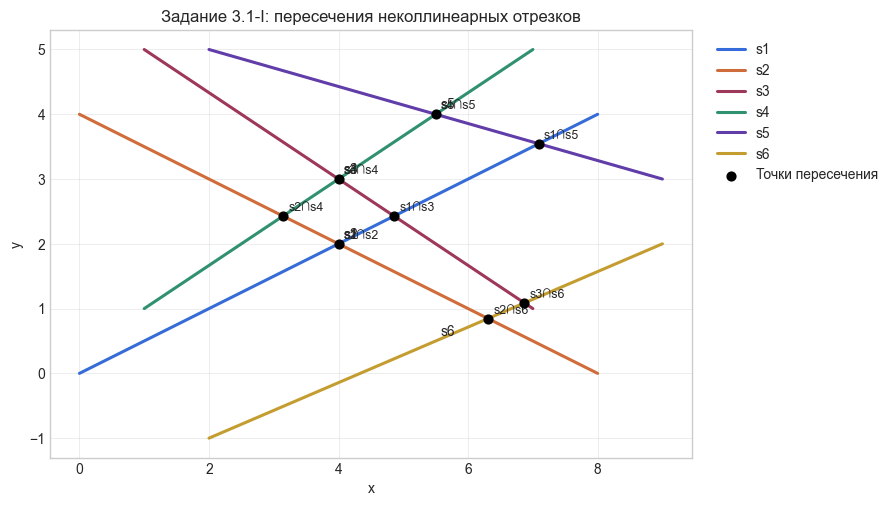

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_segments(ax, segments_proper)

intersection_points = np.array([point for _, point in line_results])
ax.scatter(intersection_points[:, 0], intersection_points[:, 1], color="black", s=40, zorder=5, label="Точки пересечения")
for pair, point in line_results:
    ax.text(point[0] + 0.08, point[1] + 0.08, f"{pair[0]}∩{pair[1]}", fontsize=9)

ax.set_title("Задание 3.1-I: пересечения неколлинеарных отрезков")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


### Часть II. Добавление коллинеарных отрезков

Адаптация алгоритмов:

- для метода косых произведений дополнительно рассматривается случай, когда все четыре ориентации равны нулю;
- для заметающей прямой коллинеарные пересечения с наложением добавляются как отдельные события пересечения, а коллинеарные непересекающиеся пары фиксируются отдельным списком.


In [6]:
cross_all_results, cross_collinear_disjoint = intersections_by_cross_products(segments_all, include_collinear=True)
sweep_all_results, sweep_collinear_disjoint = adapted_sweep_line(segments_all)

cross_intersection_pairs = {pair for pair, _, _ in cross_all_results}
sweep_intersection_pairs = {pair for pair, _, _ in sweep_all_results}

assert cross_intersection_pairs == sweep_intersection_pairs
assert set(cross_collinear_disjoint) == set(sweep_collinear_disjoint)

print_intersection_list("Адаптированный метод косых произведений:", cross_all_results)
print("Коллинеарные пары без пересечения (метод косых произведений):", cross_collinear_disjoint)
print()

print_intersection_list("Адаптированная заметающая прямая:", sweep_all_results)
print("Коллинеарные пары без пересечения (заметающая прямая):", sweep_collinear_disjoint)
print()

overlap_geometry = next(geometry for pair, kind, geometry in cross_all_results if pair == ('o1', 'o2') and kind == 'overlap')
print("Наложение отрезков o1 и o2:", f"[{format_point(overlap_geometry[0])}, {format_point(overlap_geometry[1])}]")


Адаптированный метод косых произведений:
  s1 - s2: proper, (4.000, 2.000)
  s1 - s3: proper, (4.857, 2.429)
  s1 - s5: proper, (7.091, 3.545)
  s2 - s4: proper, (3.143, 2.429)
  s2 - s6: proper, (6.308, 0.846)
  s3 - s4: proper, (4.000, 3.000)
  s3 - s6: proper, (6.870, 1.087)
  s4 - s5: proper, (5.500, 4.000)
  o1 - o2: overlap, [(12.000, 2.000), (14.000, 4.000)]

Коллинеарные пары без пересечения (метод косых произведений): [('d1', 'd2')]

Адаптированная заметающая прямая:
  s1 - s2: proper, (4.000, 2.000)
  s2 - s4: proper, (3.143, 2.429)
  s1 - s3: proper, (4.857, 2.429)
  s3 - s4: proper, (4.000, 3.000)
  s2 - s6: proper, (6.308, 0.846)
  s3 - s6: proper, (6.870, 1.087)
  s1 - s5: proper, (7.091, 3.545)
  s4 - s5: proper, (5.500, 4.000)
  o1 - o2: overlap, [(12.000, 2.000), (14.000, 4.000)]

Коллинеарные пары без пересечения (заметающая прямая): [('d1', 'd2')]

Наложение отрезков o1 и o2: [(12.000, 2.000), (14.000, 4.000)]


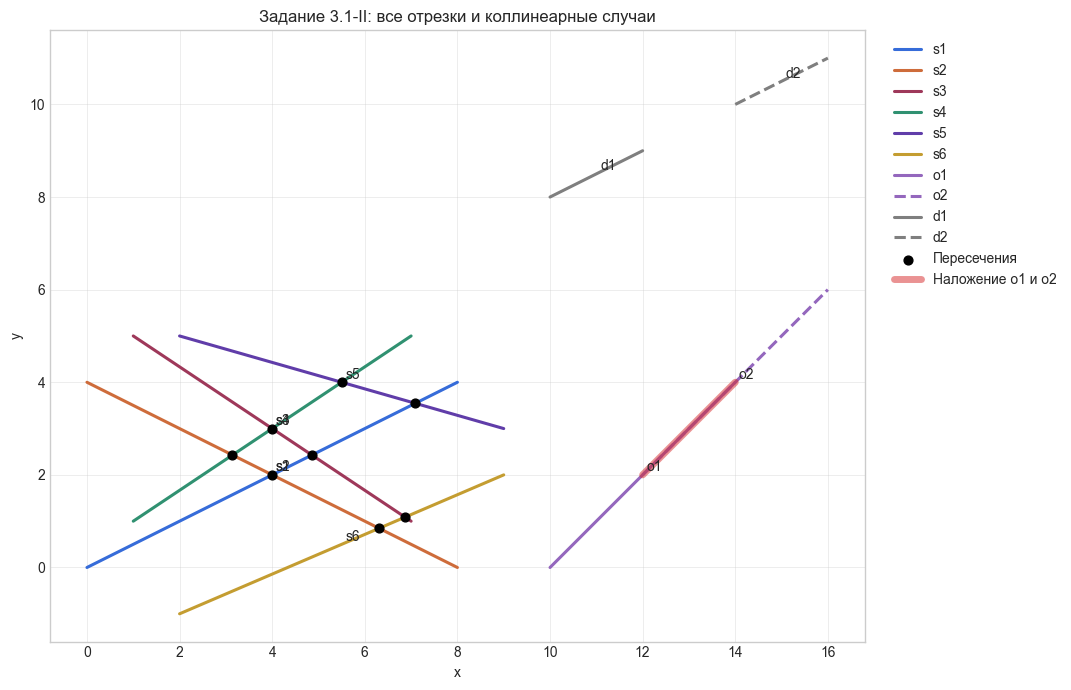

In [7]:
styles = {
    "o1": {"color": "tab:purple"},
    "o2": {"color": "tab:purple", "linestyle": "--"},
    "d1": {"color": "tab:gray"},
    "d2": {"color": "tab:gray", "linestyle": "--"},
}

fig, ax = plt.subplots(figsize=(11, 7))
plot_segments(ax, segments_all, styles=styles)

proper_points = [geometry for pair, kind, geometry in cross_all_results if kind in {"proper", "touch"}]
if proper_points:
    proper_points = np.array(proper_points)
    ax.scatter(proper_points[:, 0], proper_points[:, 1], color="black", s=40, zorder=5, label="Пересечения")

ax.plot(overlap_geometry[:, 0], overlap_geometry[:, 1], color="tab:red", linewidth=5, alpha=0.5, label="Наложение o1 и o2")
ax.set_title("Задание 3.1-II: все отрезки и коллинеарные случаи")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


## Задание 3.2. Локализация точки относительно многоугольника

Возьмем простой невыпуклый восьмиугольник

`P = ((0, 0), (3, 1), (6, 0), (8, 3), (6, 6), (3, 5), (1, 7), (-1, 3))`

и набор точек `p1, ..., p10`.

Положение точки определяется двумя методами:

- угловым методом: суммируется ориентированный угол между векторами к соседним вершинам;
- лучевым методом: считаются пересечения с горизонтальным лучом вправо.

Перед обоими методами выполняется явная проверка попадания на границу многоугольника.


In [8]:
polygon = np.array([
    (0.0, 0.0),
    (3.0, 1.0),
    (6.0, 0.0),
    (8.0, 3.0),
    (6.0, 6.0),
    (3.0, 5.0),
    (1.0, 7.0),
    (-1.0, 3.0),
])

points = {
    "p1": np.array([3.0, 3.0]),
    "p2": np.array([6.5, 1.5]),
    "p3": np.array([3.0, 1.0]),
    "p4": np.array([0.0, 0.0]),
    "p5": np.array([2.0, 6.0]),
    "p6": np.array([7.5, 5.5]),
    "p7": np.array([2.5, 0.2]),
    "p8": np.array([-0.5, 2.5]),
    "p9": np.array([4.0, 6.5]),
    "p10": np.array([5.8, 5.7]),
}

angle_result = {name: point_position_angle(point, polygon) for name, point in points.items()}
ray_result = {name: point_position_ray(point, polygon) for name, point in points.items()}

assert angle_result == ray_result
print_point_report("Классификация точек для исходного многоугольника:", points, angle_result, ray_result)


Классификация точек для исходного многоугольника:
  p1: (3.000, 3.000) | угловой метод = inside | лучевой метод = inside
  p2: (6.500, 1.500) | угловой метод = inside | лучевой метод = inside
  p3: (3.000, 1.000) | угловой метод = boundary | лучевой метод = boundary
  p4: (0.000, 0.000) | угловой метод = boundary | лучевой метод = boundary
  p5: (2.000, 6.000) | угловой метод = boundary | лучевой метод = boundary
  p6: (7.500, 5.500) | угловой метод = outside | лучевой метод = outside
  p7: (2.500, 0.200) | угловой метод = outside | лучевой метод = outside
  p8: (-0.500, 2.500) | угловой метод = inside | лучевой метод = inside
  p9: (4.000, 6.500) | угловой метод = outside | лучевой метод = outside
  p10: (5.800, 5.700) | угловой метод = inside | лучевой метод = inside



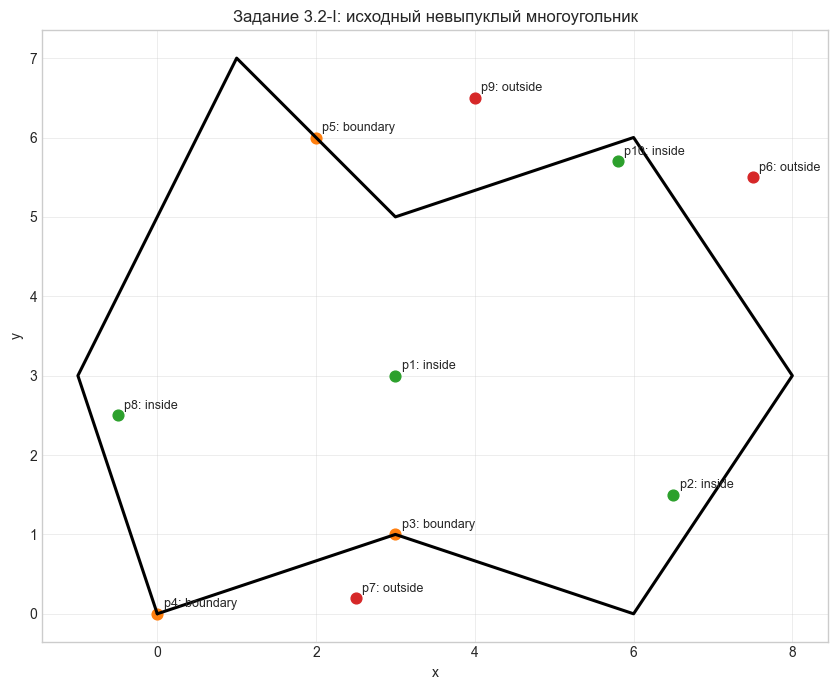

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_polygon_with_points(ax, polygon, points, ray_result, "Задание 3.2-I: исходный невыпуклый многоугольник")
plt.tight_layout()
plt.show()


### Часть II. Многоугольник с горизонтальными вершинами

Изменим многоугольник так, чтобы три вершины лежали на одной горизонтали `y = 0`,
причем две из них соседние:

`P* = ((0, 0), (2, 0), (4, 0), (7, 2), (5, 5), (2, 6), (3, 3), (-1, 2))`

Доработки алгоритмов:

- угловой метод: сохраняется предварительная проверка попадания на границу;
- лучевой метод: используются полуинтервалы `(y_i > y0) != (y_j > y0)` и игнорируются горизонтальные ребра, поэтому вершины на луче не считаются дважды.


In [10]:
polygon_horizontal = np.array([
    (0.0, 0.0),
    (2.0, 0.0),
    (4.0, 0.0),
    (7.0, 2.0),
    (5.0, 5.0),
    (2.0, 6.0),
    (3.0, 3.0),
    (-1.0, 2.0),
])

points_horizontal = {
    "q1": np.array([3.0, 1.0]),
    "q2": np.array([3.0, 3.0]),
    "q3": np.array([1.0, 0.0]),
    "q4": np.array([2.5, 0.2]),
    "q5": np.array([6.5, 1.5]),
    "q6": np.array([4.5, 4.8]),
    "q7": np.array([7.2, 4.0]),
    "q8": np.array([2.0, 6.0]),
    "q9": np.array([5.0, 0.0]),
    "q10": np.array([4.0, 0.0]),
}

angle_result_horizontal = {
    name: point_position_angle(point, polygon_horizontal)
    for name, point in points_horizontal.items()
}
ray_result_horizontal = {
    name: point_position_ray(point, polygon_horizontal)
    for name, point in points_horizontal.items()
}

assert angle_result_horizontal == ray_result_horizontal
print_point_report(
    "Классификация точек для модифицированного многоугольника:",
    points_horizontal,
    angle_result_horizontal,
    ray_result_horizontal,
)


Классификация точек для модифицированного многоугольника:
  q1: (3.000, 1.000) | угловой метод = inside | лучевой метод = inside
  q2: (3.000, 3.000) | угловой метод = boundary | лучевой метод = boundary
  q3: (1.000, 0.000) | угловой метод = boundary | лучевой метод = boundary
  q4: (2.500, 0.200) | угловой метод = inside | лучевой метод = inside
  q5: (6.500, 1.500) | угловой метод = outside | лучевой метод = outside
  q6: (4.500, 4.800) | угловой метод = inside | лучевой метод = inside
  q7: (7.200, 4.000) | угловой метод = outside | лучевой метод = outside
  q8: (2.000, 6.000) | угловой метод = boundary | лучевой метод = boundary
  q9: (5.000, 0.000) | угловой метод = outside | лучевой метод = outside
  q10: (4.000, 0.000) | угловой метод = boundary | лучевой метод = boundary



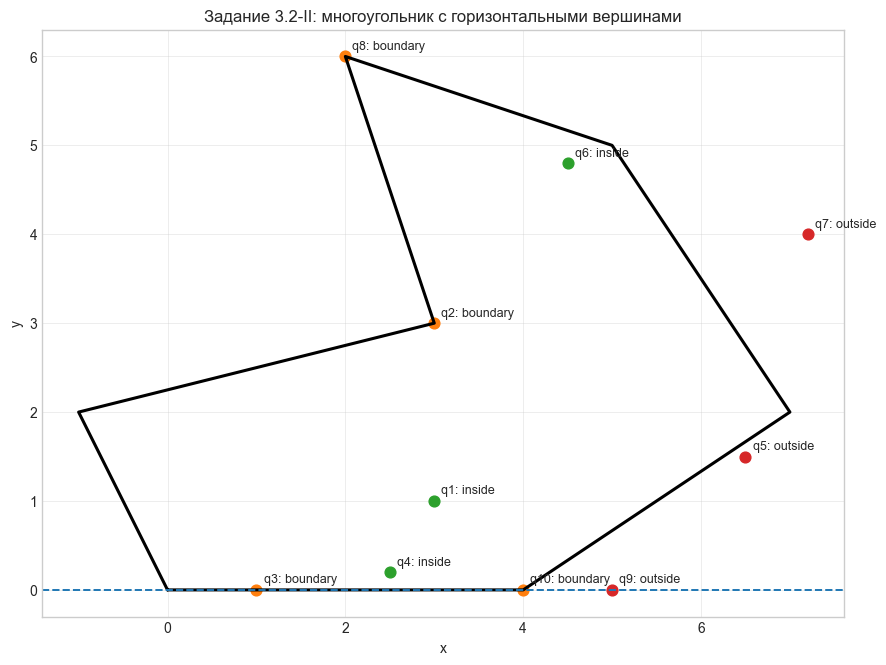

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_polygon_with_points(ax, polygon_horizontal, points_horizontal, ray_result_horizontal, "Задание 3.2-II: многоугольник с горизонтальными вершинами")
ax.axhline(0.0, color="tab:blue", linestyle="--", linewidth=1.4)
plt.tight_layout()
plt.show()


## Вывод

В ноутбуке выполнена лабораторная №3:
- найдены пересечения отрезков по уравнениям прямых, методом косых произведений и методом заметающей прямой;
- коллинеарные случаи с наложением и без наложения отдельно обработаны и визуализированы;
- положение точек относительно невыпуклого многоугольника найдено угловым и лучевым методами;
- для модифицированного многоугольника с горизонтальными вершинами применены устойчивые версии алгоритмов.
